# Programmable Mitochondrial Systems *In Silico*

**Author:** Mark I.R. Petalcorin

## Overview

This notebook presents a mechanistically informed computational framework for modeling mitochondrial programmability as a serial control problem. The workflow simulates how different cargo classes, including peptides, small molecules, nanoparticles, and nucleic acids, move through sequential biological barriers such as cell entry, intracellular trafficking, mitochondrial docking, membrane translocation, retention, and downstream engagement. It then quantifies overall mitochondrial programmability, functional rescue, and bottleneck structure using synthetic datasets, descriptive analysis, dimensionality reduction, clustering, and supervised machine learning. The notebook is intended as a hypothesis-generating tool for exploring how cargo physics, mitochondrial energetics, and organelle-specific constraints jointly shape successful mitochondrial delivery and function.

## Notebook Structure

### 1. Imports and setup
Loads Python libraries for numerical simulation, data handling, visualization, dimensionality reduction, clustering, and machine learning.

### 2. Biological assumptions and benchmark ranges
Defines the biologically motivated parameter ranges for mitochondrial membrane potential, ATP availability, ROS, OCR, and other variables that shape mitochondrial access and function.

### 3. Helper functions
Implements the mathematical functions used throughout the notebook, including logistic probability mapping, safe logarithmic transforms, scaling functions, and electrochemical accumulation terms.

### 4. Cargo classes, cell states, and targeting modes
Defines the simulated cargo categories, cellular backgrounds, and targeting contexts used to generate the design space.

### 5. Main simulation framework
Generates the synthetic mitochondrial programmability dataset by simulating the serial barrier probabilities for cell entry, trafficking, docking, translocation, retention, and engagement, followed by downstream functional rescue.

### 6. Longitudinal simulation
Builds a time-resolved synthetic dataset to track ATP, OCR, ROS, and mitochondrial membrane potential across multiple simulated time points.

### 7. Data export
Saves the generated datasets in CSV format for downstream analysis and reuse.

### 8. Descriptive statistics and grouped summaries
Summarizes the simulated data globally and by cargo class or cell state to identify broad trends in programmability and rescue.

### 9. Mechanistic visualizations
Creates plots showing the relationships between mitochondrial accumulation, membrane potential, targeting features, retention, and functional output.

### 10. Correlation and structure analysis
Uses correlation heatmaps, principal component analysis, t-SNE, and clustering to examine the structure of the synthetic design space.

### 11. Machine learning for binary success prediction
Trains classification models to predict successful mitochondrial programming and evaluates performance using ROC-AUC, precision-recall AUC, accuracy, and F1 score.

### 12. Machine learning for continuous rescue prediction
Trains regression models to predict the continuous functional rescue score and evaluates model performance using RMSE and R².

### 13. Feature-importance analysis
Uses permutation importance and related methods to identify the variables that contribute most strongly to binary success and functional rescue.

### 14. Bottleneck and sensitivity analysis
Identifies the weakest barrier in each simulated design and explores how key parameters affect predicted mitochondrial programmability and functional rescue.

### 15. Summary and exported outputs
Collects the major summary tables, plots, and model outputs generated by the notebook.

In [1]:

# CELL 1. Imports and notebook settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, Tuple, List

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    f1_score, mean_squared_error, r2_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Imports loaded.")

Imports loaded.


In [2]:

# CELL 2. Literature-inspired benchmark assumptions

# These are simulation priors motivated by PubMed-indexed mitochondrial biology:
#
# 1) Mitochondrial protein import depends on TOM/TIM machinery,
#    membrane potential, and ATP/PAM motor activity.
# 2) Lipophilic cations accumulate in mitochondria because of
#    large negative-inside membrane potential.
# 3) Matrix engagement and nucleoid access are downstream barriers.
#
# The values below are intentionally broad to reflect heterogeneity
# across cell types, cargo classes, and disease states.

LITERATURE_BENCHMARKS = {
    "delta_psi_m_mV_range_normal": (-180, -130),   # literature-inspired, broad healthy range
    "delta_psi_m_mV_range_dysfunctional": (-140, -90),
    "delta_psi_p_mV_range": (-70, -20),           # broad mammalian cell prior for simulation
    "atp_rel_range": (0.3, 1.3),                  # relative ATP availability
    "tpp_mito_accumulation_fold_typical": (100, 500),
    "tpp_cell_accumulation_fold_typical": (5, 10),
    "tom_tim_import_dependency": "high",
    "pam_atp_dependency": "high",
    "nucleoid_accessibility_range": (0.1, 1.0),
    "ros_rel_range": (0.5, 3.0),
    "ocr_rel_range": (0.3, 1.4)
}

for k, v in LITERATURE_BENCHMARKS.items():
    print(f"{k}: {v}")

delta_psi_m_mV_range_normal: (-180, -130)
delta_psi_m_mV_range_dysfunctional: (-140, -90)
delta_psi_p_mV_range: (-70, -20)
atp_rel_range: (0.3, 1.3)
tpp_mito_accumulation_fold_typical: (100, 500)
tpp_cell_accumulation_fold_typical: (5, 10)
tom_tim_import_dependency: high
pam_atp_dependency: high
nucleoid_accessibility_range: (0.1, 1.0)
ros_rel_range: (0.5, 3.0)
ocr_rel_range: (0.3, 1.4)


In [3]:

# CELL 3. Helper functions

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def clip01(x):
    return np.clip(x, 0.0, 1.0)

def minmax_scale(x, xmin, xmax):
    return (x - xmin) / (xmax - xmin + 1e-9)

def zscore_scale(x, mean, std):
    return (x - mean) / (std + 1e-9)

def log10_safe(x):
    return np.log10(np.maximum(x, 1e-12))

def nernst_accumulation_fold(z_charge, delta_psi_total_mV, temp_c=37.0):
    """
    Approximate fold accumulation using a base-10 Nernst-style relation.
    For positive charges and negative-inside potential, accumulation increases.

    log10(C_in/C_out) ≈ -(z * ΔΨ) / 61.5 mV at 37 C

    Here ΔΨ is negative inside, so the ratio becomes positive for cations.
    """
    return 10 ** (-(z_charge * delta_psi_total_mV) / 61.5)

def bounded_normal(mean, sd, low, high, size):
    x = rng.normal(mean, sd, size)
    return np.clip(x, low, high)

def bounded_uniform(low, high, size):
    return rng.uniform(low, high, size)

In [4]:

# CELL 4. Cargo, cell-state, and disease priors

cargo_types = ["peptide", "nucleic_acid", "nanoparticle", "small_molecule"]
cell_states = ["healthy", "stressed", "cancer_adapted", "inflammatory", "mitochondrial_disease"]
target_modes = ["protein_import_axis", "matrix_enzyme", "mtDNA_nucleoid", "redox_sensor", "membrane_modulator"]

cargo_type_priors = {
    "peptide": {
        "size_kDa": (3, 20),
        "charge": (2, 12),
        "hydrophobicity": (0.2, 0.8),
        "amphipathicity": (0.4, 1.0),
        "targeting_strength": (0.4, 1.0),
        "endosomal_escape": (0.2, 0.7),
        "matrix_binding": (0.3, 0.8),
        "clearance_rate": (0.3, 0.8)
    },
    "nucleic_acid": {
        "size_kDa": (10, 200),
        "charge": (-40, -5),
        "hydrophobicity": (0.0, 0.3),
        "amphipathicity": (0.0, 0.4),
        "targeting_strength": (0.1, 0.7),
        "endosomal_escape": (0.1, 0.6),
        "matrix_binding": (0.2, 0.7),
        "clearance_rate": (0.4, 0.95)
    },
    "nanoparticle": {
        "size_kDa": (100, 2000),
        "charge": (-10, 20),
        "hydrophobicity": (0.1, 0.9),
        "amphipathicity": (0.1, 0.7),
        "targeting_strength": (0.2, 0.9),
        "endosomal_escape": (0.2, 0.95),
        "matrix_binding": (0.2, 0.8),
        "clearance_rate": (0.1, 0.6)
    },
    "small_molecule": {
        "size_kDa": (0.2, 2.0),
        "charge": (-1, 3),
        "hydrophobicity": (0.2, 1.0),
        "amphipathicity": (0.0, 0.5),
        "targeting_strength": (0.1, 0.9),
        "endosomal_escape": (0.5, 1.0),
        "matrix_binding": (0.2, 0.95),
        "clearance_rate": (0.1, 0.7)
    }
}

cell_state_priors = {
    "healthy": {
        "delta_psi_m_mean": -160,
        "delta_psi_m_sd": 12,
        "delta_psi_p_mean": -50,
        "delta_psi_p_sd": 10,
        "atp_rel_mean": 1.0,
        "atp_rel_sd": 0.12,
        "tom_tim_abundance_mean": 0.85,
        "tom_tim_abundance_sd": 0.10,
        "pam_activity_mean": 0.90,
        "pam_activity_sd": 0.08,
        "nucleoid_access_mean": 0.70,
        "nucleoid_access_sd": 0.15,
        "baseline_ros_mean": 0.9,
        "baseline_ros_sd": 0.15,
        "baseline_ocr_mean": 1.0,
        "baseline_ocr_sd": 0.15
    },
    "stressed": {
        "delta_psi_m_mean": -140,
        "delta_psi_m_sd": 18,
        "delta_psi_p_mean": -40,
        "delta_psi_p_sd": 12,
        "atp_rel_mean": 0.75,
        "atp_rel_sd": 0.18,
        "tom_tim_abundance_mean": 0.70,
        "tom_tim_abundance_sd": 0.12,
        "pam_activity_mean": 0.70,
        "pam_activity_sd": 0.12,
        "nucleoid_access_mean": 0.60,
        "nucleoid_access_sd": 0.18,
        "baseline_ros_mean": 1.4,
        "baseline_ros_sd": 0.25,
        "baseline_ocr_mean": 0.8,
        "baseline_ocr_sd": 0.2
    },
    "cancer_adapted": {
        "delta_psi_m_mean": -170,
        "delta_psi_m_sd": 15,
        "delta_psi_p_mean": -35,
        "delta_psi_p_sd": 12,
        "atp_rel_mean": 0.95,
        "atp_rel_sd": 0.18,
        "tom_tim_abundance_mean": 0.80,
        "tom_tim_abundance_sd": 0.12,
        "pam_activity_mean": 0.78,
        "pam_activity_sd": 0.12,
        "nucleoid_access_mean": 0.55,
        "nucleoid_access_sd": 0.18,
        "baseline_ros_mean": 1.6,
        "baseline_ros_sd": 0.3,
        "baseline_ocr_mean": 0.9,
        "baseline_ocr_sd": 0.2
    },
    "inflammatory": {
        "delta_psi_m_mean": -145,
        "delta_psi_m_sd": 18,
        "delta_psi_p_mean": -30,
        "delta_psi_p_sd": 12,
        "atp_rel_mean": 0.72,
        "atp_rel_sd": 0.18,
        "tom_tim_abundance_mean": 0.68,
        "tom_tim_abundance_sd": 0.12,
        "pam_activity_mean": 0.65,
        "pam_activity_sd": 0.12,
        "nucleoid_access_mean": 0.52,
        "nucleoid_access_sd": 0.18,
        "baseline_ros_mean": 1.8,
        "baseline_ros_sd": 0.35,
        "baseline_ocr_mean": 0.75,
        "baseline_ocr_sd": 0.18
    },
    "mitochondrial_disease": {
        "delta_psi_m_mean": -120,
        "delta_psi_m_sd": 20,
        "delta_psi_p_mean": -35,
        "delta_psi_p_sd": 12,
        "atp_rel_mean": 0.55,
        "atp_rel_sd": 0.16,
        "tom_tim_abundance_mean": 0.60,
        "tom_tim_abundance_sd": 0.14,
        "pam_activity_mean": 0.55,
        "pam_activity_sd": 0.14,
        "nucleoid_access_mean": 0.48,
        "nucleoid_access_sd": 0.20,
        "baseline_ros_mean": 2.1,
        "baseline_ros_sd": 0.4,
        "baseline_ocr_mean": 0.55,
        "baseline_ocr_sd": 0.16
    }
}

target_mode_bias = {
    "protein_import_axis": {"needs_presequence": 1.0, "needs_nucleoid": 0.2, "needs_membrane_rescue": 0.4},
    "matrix_enzyme": {"needs_presequence": 0.7, "needs_nucleoid": 0.2, "needs_membrane_rescue": 0.3},
    "mtDNA_nucleoid": {"needs_presequence": 0.5, "needs_nucleoid": 1.0, "needs_membrane_rescue": 0.2},
    "redox_sensor": {"needs_presequence": 0.3, "needs_nucleoid": 0.1, "needs_membrane_rescue": 0.5},
    "membrane_modulator": {"needs_presequence": 0.2, "needs_nucleoid": 0.1, "needs_membrane_rescue": 1.0}
}

print("Priors defined.")

Priors defined.


In [5]:

# CELL 5. Main simulator

def simulate_mito_programmability(n_samples: int = 12000, random_seed: int = 42) -> pd.DataFrame:
    local_rng = np.random.default_rng(random_seed)
    rows = []

    for i in range(n_samples):
        cargo_type = local_rng.choice(cargo_types, p=[0.28, 0.18, 0.20, 0.34])
        cell_state = local_rng.choice(cell_states, p=[0.22, 0.18, 0.22, 0.18, 0.20])
        target_mode = local_rng.choice(target_modes)

        cpri = cargo_type_priors[cargo_type]
        spri = cell_state_priors[cell_state]
        tbias = target_mode_bias[target_mode]

        # Cargo features
        size_kDa = local_rng.uniform(*cpri["size_kDa"])
        net_charge = local_rng.uniform(*cpri["charge"])
        hydrophobicity = local_rng.uniform(*cpri["hydrophobicity"])
        amphipathicity = local_rng.uniform(*cpri["amphipathicity"])
        targeting_strength = local_rng.uniform(*cpri["targeting_strength"])
        endosomal_escape = local_rng.uniform(*cpri["endosomal_escape"])
        matrix_binding = local_rng.uniform(*cpri["matrix_binding"])
        clearance_rate = local_rng.uniform(*cpri["clearance_rate"])

        # Biological context
        delta_psi_m = np.clip(local_rng.normal(spri["delta_psi_m_mean"], spri["delta_psi_m_sd"]), -190, -80)
        delta_psi_p = np.clip(local_rng.normal(spri["delta_psi_p_mean"], spri["delta_psi_p_sd"]), -80, -10)
        atp_rel = np.clip(local_rng.normal(spri["atp_rel_mean"], spri["atp_rel_sd"]), 0.2, 1.4)
        tom_tim_abundance = clip01(local_rng.normal(spri["tom_tim_abundance_mean"], spri["tom_tim_abundance_sd"]))
        pam_activity = clip01(local_rng.normal(spri["pam_activity_mean"], spri["pam_activity_sd"]))
        nucleoid_access = clip01(local_rng.normal(spri["nucleoid_access_mean"], spri["nucleoid_access_sd"]))
        baseline_ros = np.clip(local_rng.normal(spri["baseline_ros_mean"], spri["baseline_ros_sd"]), 0.4, 3.5)
        baseline_ocr = np.clip(local_rng.normal(spri["baseline_ocr_mean"], spri["baseline_ocr_sd"]), 0.2, 1.6)

        # Design annotations
        has_tpp = int((cargo_type in ["small_molecule", "nanoparticle"]) and (net_charge > 0) and (hydrophobicity > 0.45))
        has_mts = int((cargo_type in ["peptide", "nucleic_acid"]) and (targeting_strength > 0.45))
        presequence_charge = np.clip(max(net_charge, 0) * local_rng.uniform(0.4, 1.0), 0, 15)
        compatibility_score = clip01(
            0.35 * targeting_strength +
            0.20 * amphipathicity +
            0.20 * tom_tim_abundance +
            0.15 * pam_activity +
            0.10 * nucleoid_access
        )

        # Electrochemical accumulation factor
        delta_psi_total = delta_psi_p + delta_psi_m
        effective_charge = np.clip(net_charge, -2, 3)
        raw_accum_fold = nernst_accumulation_fold(effective_charge, delta_psi_total)

        # Damp Nernst accumulation for bulky particles and anionic nucleic acids
        size_penalty = np.exp(-size_kDa / 400.0)
        chemistry_gate = (
            1.25 * has_tpp +
            1.00 * has_mts +
            0.55 * (cargo_type == "peptide") +
            0.75 * (cargo_type == "small_molecule") +
            0.45 * (cargo_type == "nanoparticle") +
            0.20 * (cargo_type == "nucleic_acid")
        )
        mito_accum_fold = raw_accum_fold * size_penalty * chemistry_gate
        mito_accum_log10 = np.clip(log10_safe(mito_accum_fold), -2, 5)

        # Step 1: Cell entry
        p_cell = sigmoid(
            1.6
            - 0.010 * size_kDa
            + 0.20 * hydrophobicity
            + 0.10 * np.clip(net_charge, -5, 5)
            + 0.90 * endosomal_escape
            + 0.35 * (cargo_type == "small_molecule")
            + 0.15 * (cargo_type == "peptide")
            - 0.40 * (cargo_type == "nucleic_acid")
            - 0.15 * (cargo_type == "nanoparticle")
        )
        p_cell = clip01(p_cell)

        # Step 2: Intracellular trafficking
        p_traffic = sigmoid(
            0.8
            + 0.80 * endosomal_escape
            + 0.35 * targeting_strength
            - 0.006 * size_kDa
            - 0.25 * (baseline_ros - 1.0)
            + 0.15 * (cargo_type == "peptide")
            + 0.10 * (cargo_type == "small_molecule")
            - 0.20 * (cargo_type == "nucleic_acid")
        )
        p_traffic = clip01(p_traffic)

        # Step 3: Mitochondrial docking
        p_dock = sigmoid(
            -0.2
            + 1.10 * targeting_strength
            + 0.55 * tom_tim_abundance
            + 0.40 * has_tpp
            + 0.45 * has_mts
            + 0.20 * amphipathicity
            - 0.10 * (baseline_ros - 1.0)
        )
        p_dock = clip01(p_dock)

        # Step 4: Membrane translocation (TIM/TOM/PAM inspired)
        # Strongly favors presequence-like charge, amphipathicity, delta_psi_m, ATP, and lower size burden
        p_transloc = sigmoid(
            -1.4
            + 0.20 * presequence_charge
            + 1.00 * amphipathicity
            + 0.020 * abs(delta_psi_m)
            + 1.00 * atp_rel
            + 0.60 * pam_activity
            + 0.50 * tom_tim_abundance
            + 0.20 * has_mts
            + 0.15 * has_tpp
            - 0.012 * size_kDa
            - 0.45 * (cargo_type == "nanoparticle")
            - 0.55 * (cargo_type == "nucleic_acid")
        )
        p_transloc = clip01(p_transloc)

        # Step 5: Matrix retention
        p_retain = sigmoid(
            -0.1
            + 1.00 * matrix_binding
            + 0.50 * mito_accum_log10
            + 0.40 * compatibility_score
            - 1.10 * clearance_rate
            - 0.12 * (baseline_ros - 1.0)
        )
        p_retain = clip01(p_retain)

        # Step 6: Target engagement
        target_affinity = clip01(
            0.35 * targeting_strength +
            0.25 * matrix_binding +
            0.20 * amphipathicity +
            0.20 * local_rng.uniform(0, 1)
        )

        engagement_need_preseq = tbias["needs_presequence"]
        engagement_need_nucleoid = tbias["needs_nucleoid"]
        engagement_need_membrane = tbias["needs_membrane_rescue"]

        p_engage = sigmoid(
            -0.5
            + 1.00 * target_affinity
            + 0.75 * nucleoid_access * engagement_need_nucleoid
            + 0.55 * presequence_charge / 10.0 * engagement_need_preseq
            + 0.40 * mito_accum_log10 * engagement_need_membrane
            + 0.45 * compatibility_score
            - 0.25 * clearance_rate
        )
        p_engage = clip01(p_engage)

        # Serial control score
        phi_prog = p_cell * p_traffic * p_dock * p_transloc * p_retain * p_engage

        # Functional rescue depends on serial success and disease burden
        disease_deficit = clip01(
            0.35 * (1 - atp_rel) +
            0.25 * (1 - minmax_scale(abs(delta_psi_m), 80, 190)) +
            0.20 * minmax_scale(baseline_ros, 0.4, 3.5) +
            0.20 * (1 - baseline_ocr / 1.6)
        )

        mode_match = clip01(
            0.40 * (target_mode == "protein_import_axis") * has_mts +
            0.35 * (target_mode == "mtDNA_nucleoid") * nucleoid_access +
            0.30 * (target_mode == "membrane_modulator") * has_tpp +
            0.20 * (target_mode == "matrix_enzyme") * matrix_binding +
            0.20 * (target_mode == "redox_sensor") * hydrophobicity
        )

        functional_gain = clip01(
            0.55 * phi_prog +
            0.25 * disease_deficit +
            0.20 * mode_match
        )

        # Post-treatment outputs
        # ATP/OCR increase with gain; ROS decreases with gain
        atp_post = np.clip(atp_rel + 0.75 * functional_gain - 0.10 * clearance_rate + local_rng.normal(0, 0.05), 0.15, 1.8)
        ocr_post = np.clip(baseline_ocr + 0.60 * functional_gain - 0.08 * clearance_rate + local_rng.normal(0, 0.05), 0.15, 1.8)
        ros_post = np.clip(baseline_ros - 0.90 * functional_gain + 0.12 * clearance_rate + local_rng.normal(0, 0.08), 0.2, 4.0)
        psi_m_post = np.clip(abs(delta_psi_m) + 35.0 * functional_gain - 5.0 * clearance_rate + local_rng.normal(0, 4.0), 70, 210)

        # Normalized functional score
        g_func = (
            0.30 * (atp_post / max(atp_rel, 0.15)) +
            0.25 * (psi_m_post / max(abs(delta_psi_m), 70)) +
            0.25 * (ocr_post / max(baseline_ocr, 0.15)) -
            0.20 * (ros_post / max(baseline_ros, 0.2))
        )

        # Rescale G_func to a more convenient range
        g_func_scaled = clip01((g_func + 0.25) / 2.0)

        # Final outcome label
        successful_programming = int((phi_prog > 0.08) and (g_func_scaled > 0.50))
        strong_rescue = int((g_func_scaled > 0.65) and (successful_programming == 1))

        rows.append({
            "sample_id": i,
            "cargo_type": cargo_type,
            "cell_state": cell_state,
            "target_mode": target_mode,

            "size_kDa": size_kDa,
            "net_charge": net_charge,
            "hydrophobicity": hydrophobicity,
            "amphipathicity": amphipathicity,
            "targeting_strength": targeting_strength,
            "endosomal_escape": endosomal_escape,
            "matrix_binding": matrix_binding,
            "clearance_rate": clearance_rate,
            "has_tpp": has_tpp,
            "has_mts": has_mts,
            "presequence_charge": presequence_charge,

            "delta_psi_m_mV": delta_psi_m,
            "delta_psi_p_mV": delta_psi_p,
            "delta_psi_total_mV": delta_psi_total,
            "atp_rel_pre": atp_rel,
            "tom_tim_abundance": tom_tim_abundance,
            "pam_activity": pam_activity,
            "nucleoid_access": nucleoid_access,
            "baseline_ros": baseline_ros,
            "baseline_ocr": baseline_ocr,

            "raw_accum_fold": raw_accum_fold,
            "mito_accum_fold": mito_accum_fold,
            "mito_accum_log10": mito_accum_log10,
            "target_affinity": target_affinity,
            "compatibility_score": compatibility_score,

            "P_cell": p_cell,
            "P_traffic": p_traffic,
            "P_dock": p_dock,
            "P_transloc": p_transloc,
            "P_retain": p_retain,
            "P_engage": p_engage,
            "Phi_prog": phi_prog,

            "ATP_post": atp_post,
            "OCR_post": ocr_post,
            "ROS_post": ros_post,
            "Psi_m_abs_post": psi_m_post,
            "G_func": g_func_scaled,

            "successful_programming": successful_programming,
            "strong_rescue": strong_rescue
        })

    return pd.DataFrame(rows)

df = simulate_mito_programmability(n_samples=12000, random_seed=RANDOM_SEED)
print(df.shape)
df.head()

(12000, 43)


,sample_id,cargo_type,cell_state,target_mode,size_kDa,net_charge,hydrophobicity,amphipathicity,targeting_strength,endosomal_escape,...,P_retain,P_engage,Phi_prog,ATP_post,OCR_post,ROS_post,Psi_m_abs_post,G_func,successful_programming,strong_rescue
0,0,small_molecule,cancer_adapted,mtDNA_nucleoid,1.455262,-0.623291,0.980498,0.380570,0.728851,0.564057,...,0.334439,0.654405,0.123732,1.196793,1.199166,1.206449,160.149346,0.454561,0,0
1,1,peptide,cancer_adapted,membrane_modulator,3.744664,3.542895,0.609829,0.846857,0.980506,0.362913,...,0.927261,0.927290,0.541131,1.044403,0.998227,1.499198,166.555317,0.534809,1,0
2,2,peptide,inflammatory,redox_sensor,14.987811,9.807290,0.475349,0.741245,0.483878,0.257265,...,0.932229,0.793993,0.393756,0.868693,0.756658,1.384572,185.650269,0.490623,0,0
3,3,nucleic_acid,inflammatory,redox_sensor,115.836109,-12.563563,0.199294,0.162555,0.588412,0.183486,...,0.215736,0.423950,0.013093,0.591581,0.692269,1.878541,164.273496,0.413706,0,0
4,4,small_molecule,inflammatory,mtDNA_nucleoid,1.944517,2.115004,0.773512,0.224681,0.317793,0.548195,...,0.950426,0.716050,0.348213,0.940225,0.892227,1.401739,185.685952,0.495729,0,0


In [6]:

# CELL 6. Generate an assay-level longitudinal dataset

def make_longitudinal_dataset(df: pd.DataFrame, n_per_sample: int = 4) -> pd.DataFrame:
    time_points = ["t0", "t1", "t2", "t3"]
    rows = []

    for _, row in df.sample(min(len(df), 4000), random_state=RANDOM_SEED).iterrows():
        for t_idx, tp in enumerate(time_points[:n_per_sample]):
            frac = t_idx / (n_per_sample - 1) if n_per_sample > 1 else 1.0
            rows.append({
                "sample_id": row["sample_id"],
                "cargo_type": row["cargo_type"],
                "cell_state": row["cell_state"],
                "target_mode": row["target_mode"],
                "time_point": tp,
                "ATP_rel": np.clip(row["atp_rel_pre"] + frac * (row["ATP_post"] - row["atp_rel_pre"]) + rng.normal(0, 0.03), 0.1, 2.0),
                "OCR_rel": np.clip(row["baseline_ocr"] + frac * (row["OCR_post"] - row["baseline_ocr"]) + rng.normal(0, 0.03), 0.1, 2.0),
                "ROS_rel": np.clip(row["baseline_ros"] + frac * (row["ROS_post"] - row["baseline_ros"]) + rng.normal(0, 0.04), 0.1, 4.5),
                "Psi_m_abs": np.clip(abs(row["delta_psi_m_mV"]) + frac * (row["Psi_m_abs_post"] - abs(row["delta_psi_m_mV"])) + rng.normal(0, 2.0), 60, 220),
                "Phi_prog_static": row["Phi_prog"],
                "G_func_static": row["G_func"]
            })
    return pd.DataFrame(rows)

long_df = make_longitudinal_dataset(df, n_per_sample=4)
print(long_df.shape)
long_df.head()

(16000, 11)


,sample_id,cargo_type,cell_state,target_mode,time_point,ATP_rel,OCR_rel,ROS_rel,Psi_m_abs,Phi_prog_static,G_func_static
0,1935,peptide,mitochondrial_disease,matrix_enzyme,t0,0.411421,0.168800,2.556053,113.339812,0.271703,0.663290
1,1935,peptide,mitochondrial_disease,matrix_enzyme,t1,0.412325,0.231050,2.411208,115.542072,0.271703,0.663290
2,1935,peptide,mitochondrial_disease,matrix_enzyme,t2,0.538929,0.314640,2.321330,122.446017,0.271703,0.663290
3,1935,peptide,mitochondrial_disease,matrix_enzyme,t3,0.609991,0.444164,2.184914,123.887724,0.271703,0.663290
4,6494,small_molecule,stressed,redox_sensor,t0,0.833635,0.707658,1.565377,131.133598,0.078428,0.484283


In [7]:

# CELL 7. Save datasets

df.to_csv("simulated_mito_programmability_dataset.csv", index=False)
long_df.to_csv("simulated_mito_programmability_longitudinal.csv", index=False)

print("Saved:")
print(" - simulated_mito_programmability_dataset.csv")
print(" - simulated_mito_programmability_longitudinal.csv")

Saved:
 - simulated_mito_programmability_dataset.csv
 - simulated_mito_programmability_longitudinal.csv


In [8]:

# CELL 8. Basic descriptive statistics

display_cols = [
    "size_kDa", "net_charge", "delta_psi_m_mV", "atp_rel_pre",
    "P_cell", "P_traffic", "P_dock", "P_transloc", "P_retain", "P_engage",
    "Phi_prog", "G_func", "successful_programming", "strong_rescue"
]
print(df[display_cols].describe().T)

print("\nSuccess rate:", df["successful_programming"].mean().round(3))
print("Strong rescue rate:", df["strong_rescue"].mean().round(3))

                          count        mean         std           min  \
size_kDa                12000.0  235.512999  485.257097  2.007367e-01   
net_charge              12000.0   -0.750400   12.079858 -3.998837e+01   
delta_psi_m_mV          12000.0 -147.322791   24.083076 -1.900000e+02   
atp_rel_pre             12000.0    0.801091    0.232005  2.000000e-01   
P_cell                  12000.0    0.687043    0.359912  7.489937e-09   
P_traffic               12000.0    0.621076    0.292005  1.293338e-05   
P_dock                  12000.0    0.736859    0.080476  4.918557e-01   
P_transloc              12000.0    0.773822    0.357268  1.577398e-10   
P_retain                12000.0    0.692100    0.302227  1.292574e-01   
P_engage                12000.0    0.666957    0.173756  2.377154e-01   
Phi_prog                12000.0    0.225570    0.197896  1.187608e-24   
G_func                  12000.0    0.487424    0.052579  3.723852e-01   
successful_programming  12000.0    0.378667    0.48

In [9]:

# CELL 9. Summaries by cargo type and cell state

summary_cargo = df.groupby("cargo_type")[["Phi_prog", "G_func", "successful_programming", "strong_rescue"]].mean().sort_values("successful_programming", ascending=False)
summary_state = df.groupby("cell_state")[["Phi_prog", "G_func", "successful_programming", "strong_rescue"]].mean().sort_values("successful_programming", ascending=False)

print("By cargo type")
print(summary_cargo)

print("\nBy cell state")
print(summary_state)

By cargo type
                Phi_prog    G_func  successful_programming  strong_rescue
cargo_type                                                               
peptide         0.446070  0.530061                0.776156       0.016423
small_molecule  0.280745  0.501220                0.466603       0.005746
nanoparticle    0.013817  0.451257                0.017769       0.000000
nucleic_acid    0.016099  0.435275                0.000000       0.000000

By cell state
                       Phi_prog    G_func  successful_programming  \
cell_state                                                          
mitochondrial_disease  0.197508  0.519512                0.512955   
inflammatory           0.220958  0.490474                0.413808   
stressed               0.223600  0.488682                0.407355   
healthy                0.251290  0.471387                0.323180   
cancer_adapted         0.232710  0.469127                0.253035   

                       strong_rescue  
cell

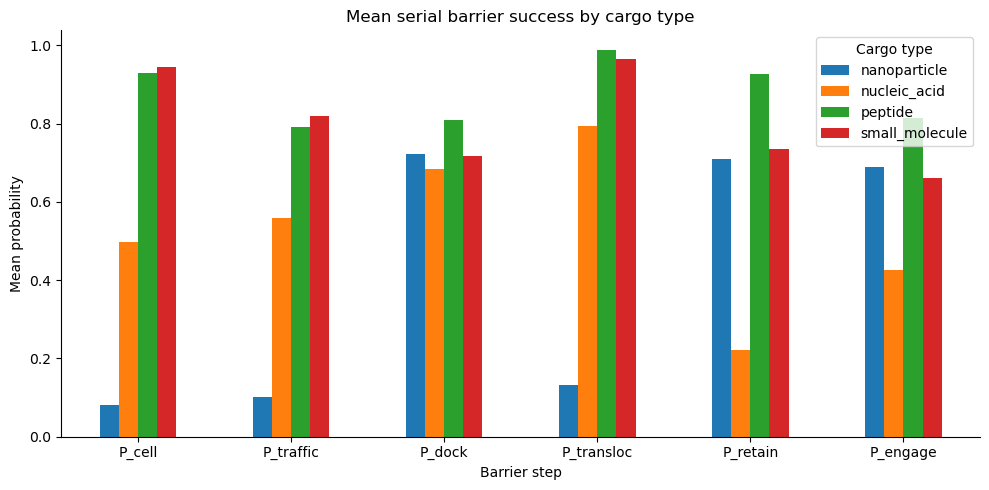

In [10]:

# CELL 10. Visualize serial barriers by cargo type

step_cols = ["P_cell", "P_traffic", "P_dock", "P_transloc", "P_retain", "P_engage"]
barrier_by_cargo = df.groupby("cargo_type")[step_cols].mean()

ax = barrier_by_cargo.T.plot(kind="bar", figsize=(10, 5))
ax.set_title("Mean serial barrier success by cargo type")
ax.set_ylabel("Mean probability")
ax.set_xlabel("Barrier step")
plt.xticks(rotation=0)
plt.legend(title="Cargo type")
plt.tight_layout()
plt.show()

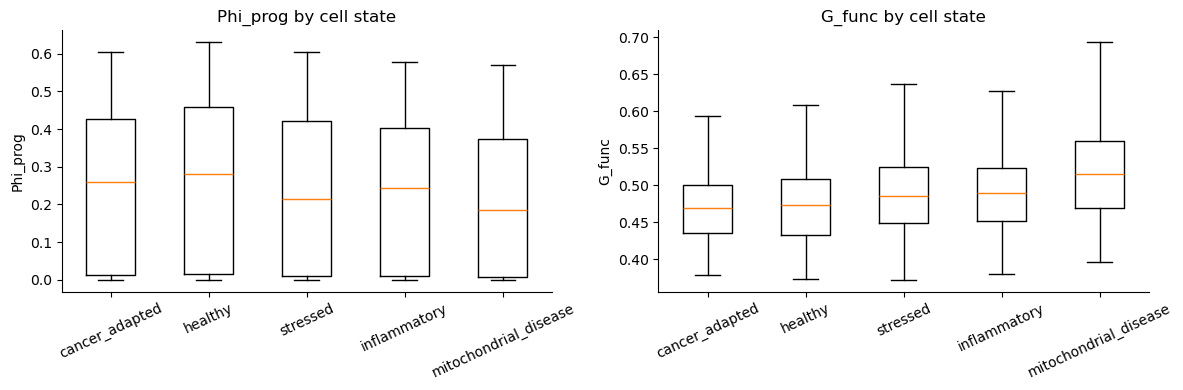

In [11]:

# CELL 11. Visualize outcomes by cell state

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

state_order = df.groupby("cell_state")["successful_programming"].mean().sort_values().index.tolist()

for i, metric in enumerate(["Phi_prog", "G_func"]):
    ax = axes[i]
    data = [df.loc[df["cell_state"] == s, metric].values for s in state_order]
    ax.boxplot(data, labels=state_order, showfliers=False)
    ax.set_title(f"{metric} by cell state")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

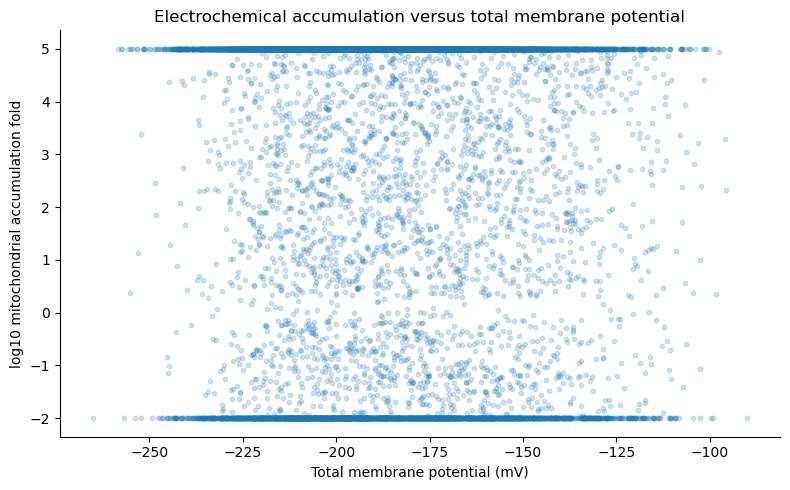

In [12]:

# CELL 12. Electrochemical accumulation visualization

plt.figure(figsize=(8, 5))
plt.scatter(df["delta_psi_total_mV"], df["mito_accum_log10"], s=10, alpha=0.2)
plt.xlabel("Total membrane potential (mV)")
plt.ylabel("log10 mitochondrial accumulation fold")
plt.title("Electrochemical accumulation versus total membrane potential")
plt.tight_layout()
plt.show()

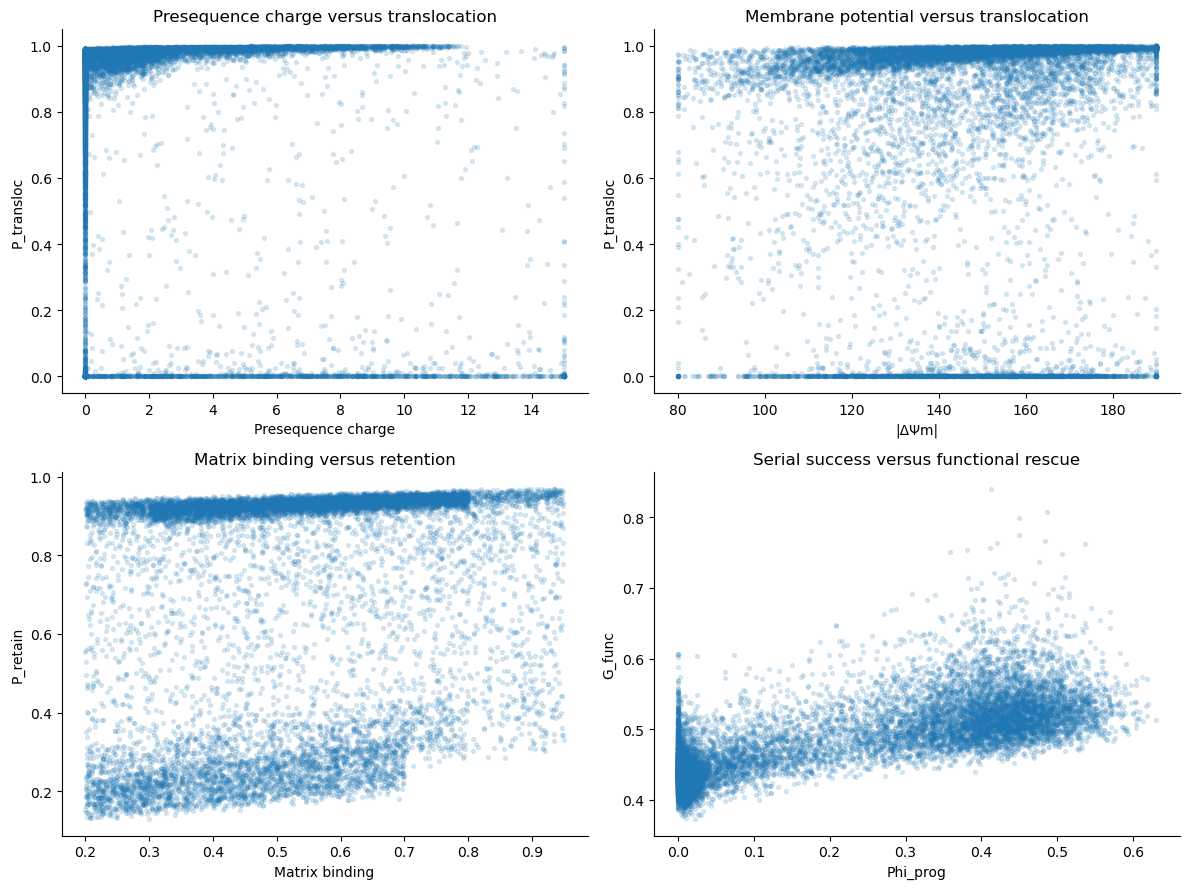

In [13]:

# CELL 13. Pairwise biological logic checks

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(df["presequence_charge"], df["P_transloc"], s=8, alpha=0.15)
axes[0, 0].set_xlabel("Presequence charge")
axes[0, 0].set_ylabel("P_transloc")
axes[0, 0].set_title("Presequence charge versus translocation")

axes[0, 1].scatter(np.abs(df["delta_psi_m_mV"]), df["P_transloc"], s=8, alpha=0.15)
axes[0, 1].set_xlabel("|ΔΨm|")
axes[0, 1].set_ylabel("P_transloc")
axes[0, 1].set_title("Membrane potential versus translocation")

axes[1, 0].scatter(df["matrix_binding"], df["P_retain"], s=8, alpha=0.15)
axes[1, 0].set_xlabel("Matrix binding")
axes[1, 0].set_ylabel("P_retain")
axes[1, 0].set_title("Matrix binding versus retention")

axes[1, 1].scatter(df["Phi_prog"], df["G_func"], s=8, alpha=0.15)
axes[1, 1].set_xlabel("Phi_prog")
axes[1, 1].set_ylabel("G_func")
axes[1, 1].set_title("Serial success versus functional rescue")

plt.tight_layout()
plt.show()

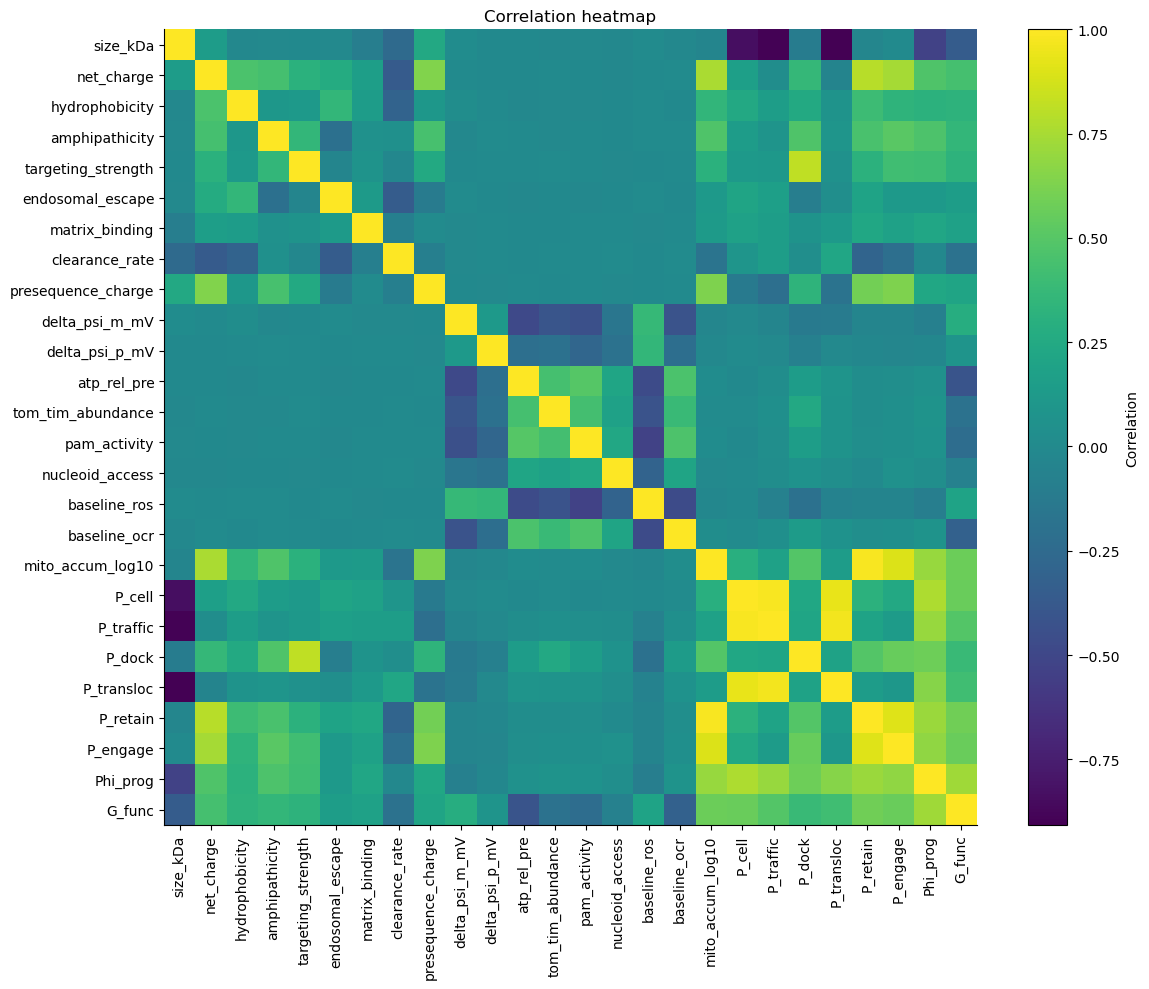

In [14]:

# CELL 14. Correlation heatmap

num_cols = [
    "size_kDa", "net_charge", "hydrophobicity", "amphipathicity", "targeting_strength",
    "endosomal_escape", "matrix_binding", "clearance_rate", "presequence_charge",
    "delta_psi_m_mV", "delta_psi_p_mV", "atp_rel_pre", "tom_tim_abundance", "pam_activity",
    "nucleoid_access", "baseline_ros", "baseline_ocr", "mito_accum_log10",
    "P_cell", "P_traffic", "P_dock", "P_transloc", "P_retain", "P_engage",
    "Phi_prog", "G_func"
]

corr = df[num_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

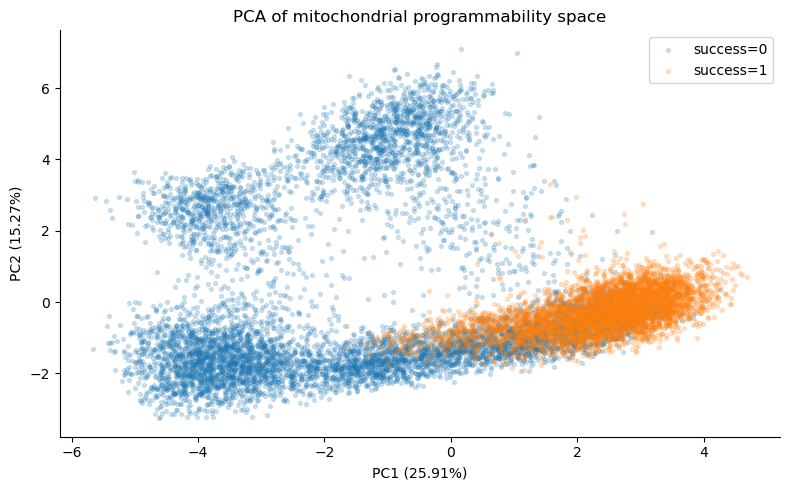

In [15]:

# CELL 15. PCA projection

pca_features = df[num_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_features)

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cargo_type": df["cargo_type"].values,
    "successful_programming": df["successful_programming"].values
})

plt.figure(figsize=(8, 5))
for label in [0, 1]:
    mask = pca_df["successful_programming"] == label
    plt.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"], s=8, alpha=0.2, label=f"success={label}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.title("PCA of mitochondrial programmability space")
plt.legend()
plt.tight_layout()
plt.show()

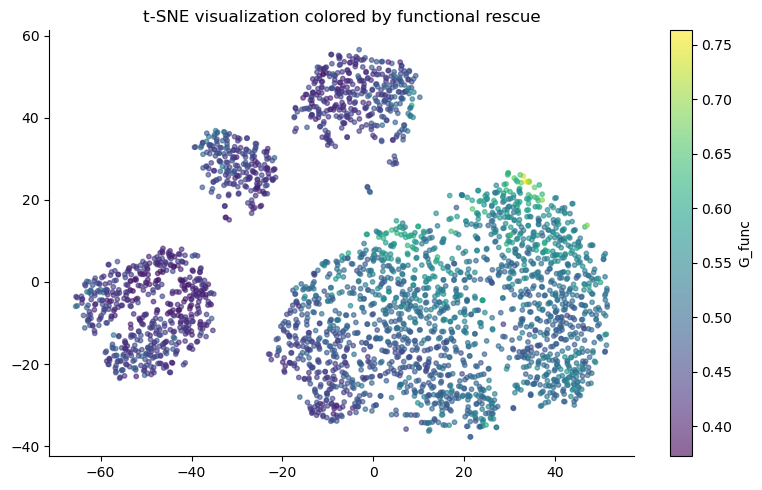

In [16]:

# CELL 16. t-SNE for nonlinear visualization

sample_vis = df.sample(3000, random_state=RANDOM_SEED).copy()
vis_num = sample_vis[num_cols]
vis_scaled = StandardScaler().fit_transform(vis_num)

tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=RANDOM_SEED)
X_tsne = tsne.fit_transform(vis_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=sample_vis["G_func"], s=10, alpha=0.6)
plt.colorbar(label="G_func")
plt.title("t-SNE visualization colored by functional rescue")
plt.tight_layout()
plt.show()

         Phi_prog    G_func  successful_programming
cluster                                            
0        0.442940  0.529784                0.772152
1        0.017670  0.435717                0.000000
2        0.001807  0.449324                0.000000
3        0.265758  0.498966                0.438088


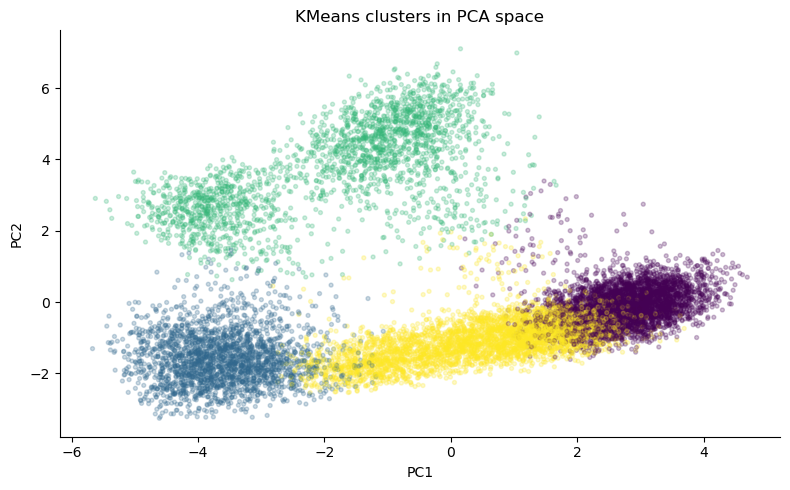

In [17]:

# CELL 17. Unsupervised clustering

kmeans = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

cluster_summary = df.assign(cluster=clusters).groupby("cluster")[["Phi_prog", "G_func", "successful_programming"]].mean()
print(cluster_summary)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, s=8, alpha=0.25)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters in PCA space")
plt.tight_layout()
plt.show()

In [18]:

# CELL 18. Prepare data for machine learning

feature_cols = [
    "cargo_type", "cell_state", "target_mode",
    "size_kDa", "net_charge", "hydrophobicity", "amphipathicity",
    "targeting_strength", "endosomal_escape", "matrix_binding", "clearance_rate",
    "has_tpp", "has_mts", "presequence_charge",
    "delta_psi_m_mV", "delta_psi_p_mV", "atp_rel_pre",
    "tom_tim_abundance", "pam_activity", "nucleoid_access",
    "baseline_ros", "baseline_ocr", "mito_accum_log10",
    "target_affinity", "compatibility_score"
]

X = df[feature_cols].copy()
y_cls = df["successful_programming"].copy()
y_reg = df["G_func"].copy()

cat_cols = ["cargo_type", "cell_state", "target_mode"]
num_cols_ml = [c for c in feature_cols if c not in cat_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols_ml),
        ("cat", categorical_transformer, cat_cols)
    ]
)

X_train, X_test, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=RANDOM_SEED, stratify=y_cls
)

_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_SEED
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Positive class rate (train):", y_train_cls.mean().round(3))
print("Positive class rate (test):", y_test_cls.mean().round(3))

Train size: (9600, 25) Test size: (2400, 25)
Positive class rate (train): 0.379
Positive class rate (test): 0.379


In [19]:

# CELL 19. Classification models

classifiers = {
    "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_SEED, n_jobs=-1, class_weight="balanced_subsample"
    ),
    "gradient_boosting": GradientBoostingClassifier(random_state=RANDOM_SEED),
    "mlp_classifier": MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu", max_iter=300, random_state=RANDOM_SEED)
}

cls_results = []

fitted_cls_models = {}

for name, model in classifiers.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train_cls)
    fitted_cls_models[name] = pipe

    y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else pipe.decision_function(X_test)
    y_pred = (y_prob >= 0.5).astype(int)

    result = {
        "model": name,
        "roc_auc": roc_auc_score(y_test_cls, y_prob),
        "pr_auc": average_precision_score(y_test_cls, y_prob),
        "accuracy": accuracy_score(y_test_cls, y_pred),
        "f1": f1_score(y_test_cls, y_pred)
    }
    cls_results.append(result)

cls_results_df = pd.DataFrame(cls_results).sort_values("roc_auc", ascending=False)
print(cls_results_df)

                 model   roc_auc    pr_auc  accuracy        f1
0  logistic_regression  0.976723  0.960435  0.910417  0.889574
2    gradient_boosting  0.973904  0.956488  0.908333  0.881466
1        random_forest  0.972492  0.953680  0.900417  0.875065
3       mlp_classifier  0.968491  0.946677  0.901667  0.870472


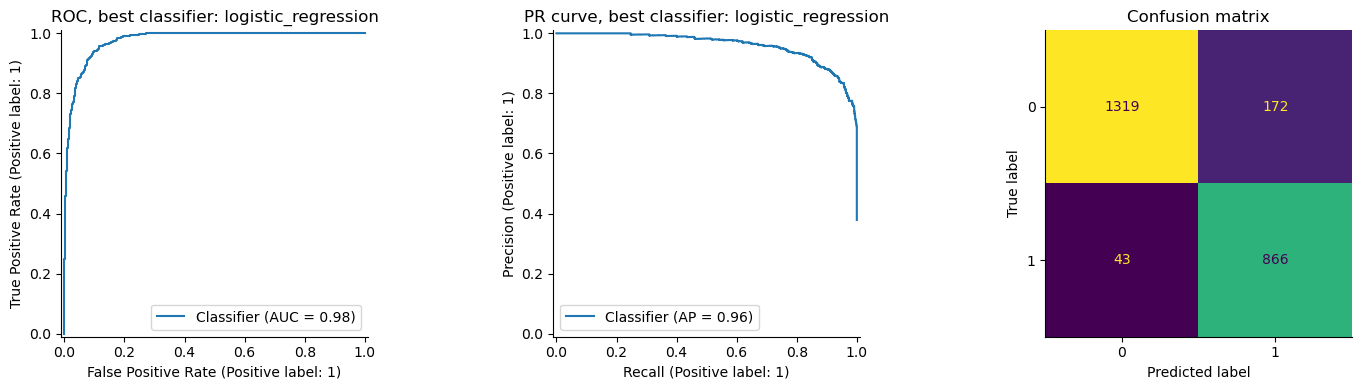

In [20]:

# CELL 20. Classification performance plots

best_cls_name = cls_results_df.iloc[0]["model"]
best_cls_model = fitted_cls_models[best_cls_name]

y_prob_best = best_cls_model.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

RocCurveDisplay.from_predictions(y_test_cls, y_prob_best, ax=axes[0])
axes[0].set_title(f"ROC, best classifier: {best_cls_name}")

PrecisionRecallDisplay.from_predictions(y_test_cls, y_prob_best, ax=axes[1])
axes[1].set_title(f"PR curve, best classifier: {best_cls_name}")

ConfusionMatrixDisplay(confusion_matrix(y_test_cls, y_pred_best)).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Confusion matrix")

plt.tight_layout()
plt.show()

                feature  importance_mean  importance_std
3              size_kDa         0.150965        0.006716
22     mito_accum_log10         0.093760        0.004754
16          atp_rel_pre         0.043228        0.002355
10       clearance_rate         0.018846        0.001286
0            cargo_type         0.017810        0.002029
21         baseline_ocr         0.014051        0.001211
12              has_mts         0.006976        0.000891
11              has_tpp         0.005840        0.000505
14       delta_psi_m_mV         0.004807        0.000823
20         baseline_ros         0.004281        0.000458
8      endosomal_escape         0.003582        0.000304
1            cell_state         0.002687        0.000473
2           target_mode         0.002566        0.000521
7    targeting_strength         0.002487        0.000455
24  compatibility_score         0.001636        0.000356


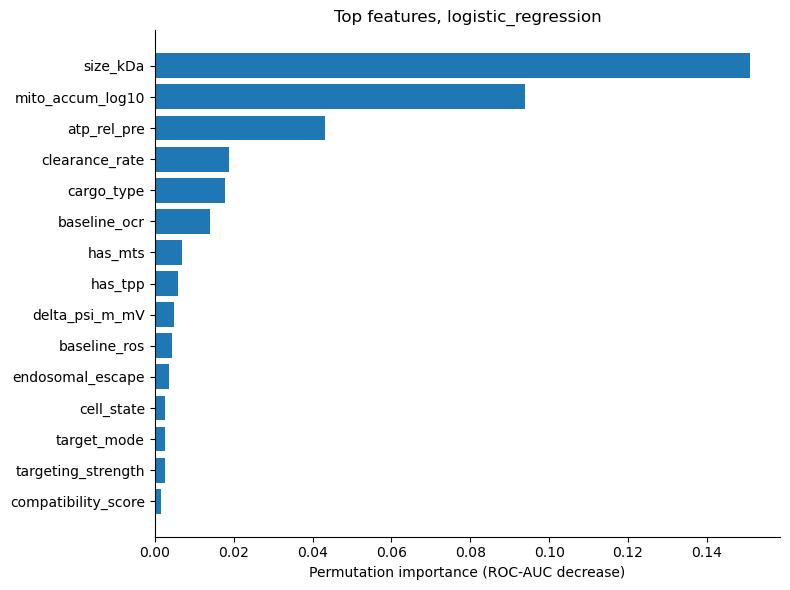

In [21]:

# CELL 21. Classification feature importance via permutation

perm = permutation_importance(
    best_cls_model, X_test, y_test_cls,
    n_repeats=8, random_state=RANDOM_SEED, scoring="roc_auc"
)

perm_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_importance.head(15))

top_perm = perm_importance.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.xlabel("Permutation importance (ROC-AUC decrease)")
plt.title(f"Top features, {best_cls_name}")
plt.tight_layout()
plt.show()

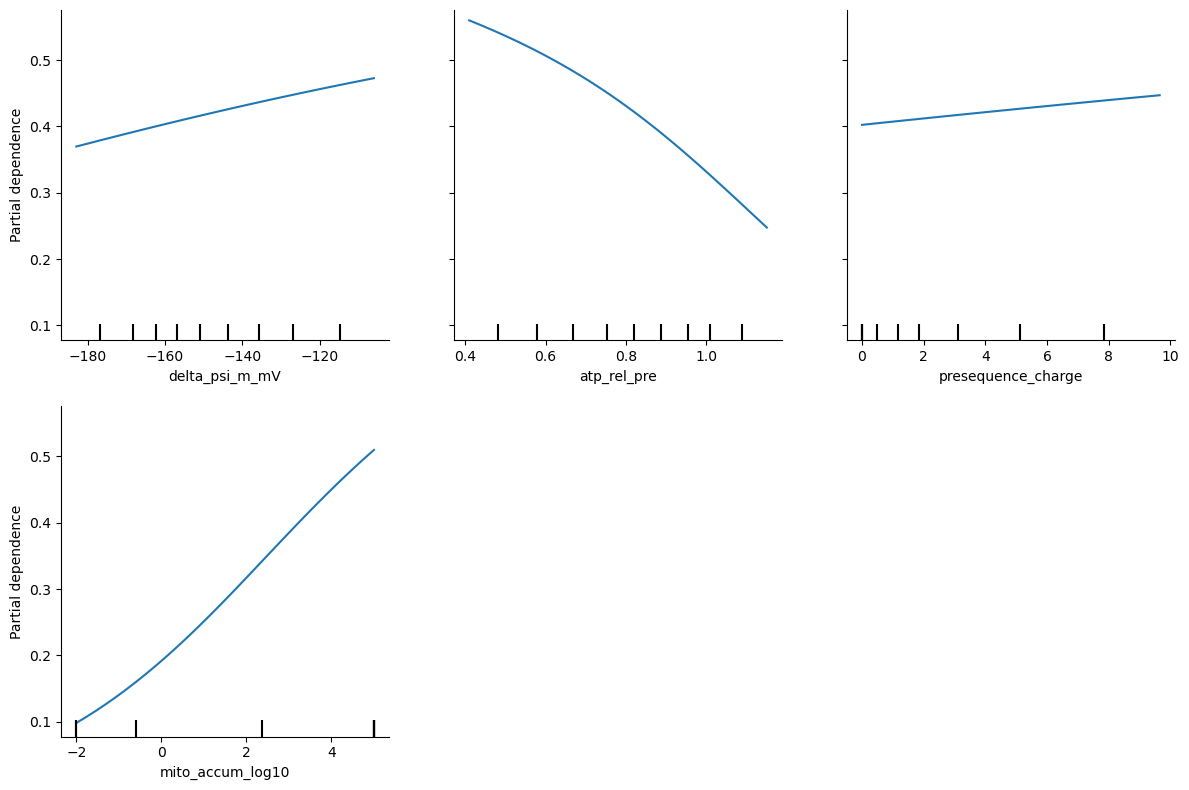

In [22]:

# CELL 22. Partial dependence for biologically important features

features_for_pdp = ["delta_psi_m_mV", "atp_rel_pre", "presequence_charge", "mito_accum_log10"]

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    best_cls_model, X_test, features_for_pdp, kind="average", ax=ax
)
plt.tight_layout()
plt.show()

In [36]:

# CELL 23. Regression models for continuous functional rescue

regressors = {
    "ridge": Ridge(alpha=1.0),
    "random_forest_regressor": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1
    ),
    "gradient_boosting_regressor": GradientBoostingRegressor(random_state=RANDOM_SEED),
    "mlp_regressor": MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=350, random_state=RANDOM_SEED)
}

reg_results = []
fitted_reg_models = {}

for name, model in regressors.items():
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train_reg)
    fitted_reg_models[name] = pipe

    y_pred = pipe.predict(X_test)

    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)

    reg_results.append({
        "model": name,
        "rmse": rmse,
        "r2": r2_score(y_test_reg, y_pred)
    })

reg_results_df = pd.DataFrame(reg_results).sort_values("r2", ascending=False)
print(reg_results_df)

                         model      rmse        r2
0                        ridge  0.050725 -0.005770
2  gradient_boosting_regressor  0.050920 -0.013547
1      random_forest_regressor  0.051471 -0.035594
3                mlp_regressor  0.062164 -0.510575


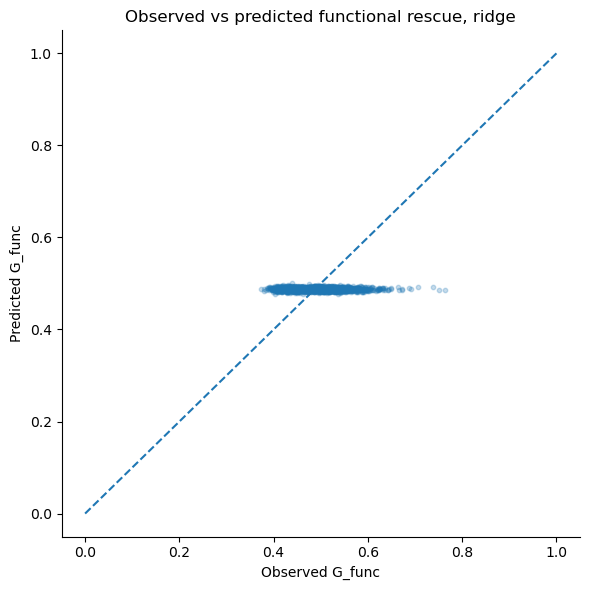

In [38]:

# CELL 24. Regression diagnostic plot

best_reg_name = reg_results_df.iloc[0]["model"]
best_reg_model = fitted_reg_models[best_reg_name]

y_pred_reg = best_reg_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg, s=10, alpha=0.25)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Observed G_func")
plt.ylabel("Predicted G_func")
plt.title(f"Observed vs predicted functional rescue, {best_reg_name}")
plt.tight_layout()
plt.show()

               feature  importance_mean  importance_std
0           cargo_type         0.003475        0.003314
1           cell_state         0.002235        0.001034
5       hydrophobicity         0.001223        0.001003
12             has_mts         0.001169        0.000402
9       matrix_binding         0.001072        0.000389
2          target_mode         0.000879        0.000847
4           net_charge         0.000637        0.001041
23     target_affinity         0.000432        0.000668
13  presequence_charge         0.000394        0.000641
10      clearance_rate         0.000208        0.000586
6       amphipathicity         0.000207        0.000424
17   tom_tim_abundance         0.000191        0.000545
16         atp_rel_pre         0.000169        0.000231
14      delta_psi_m_mV         0.000106        0.000522
22    mito_accum_log10         0.000018        0.000115


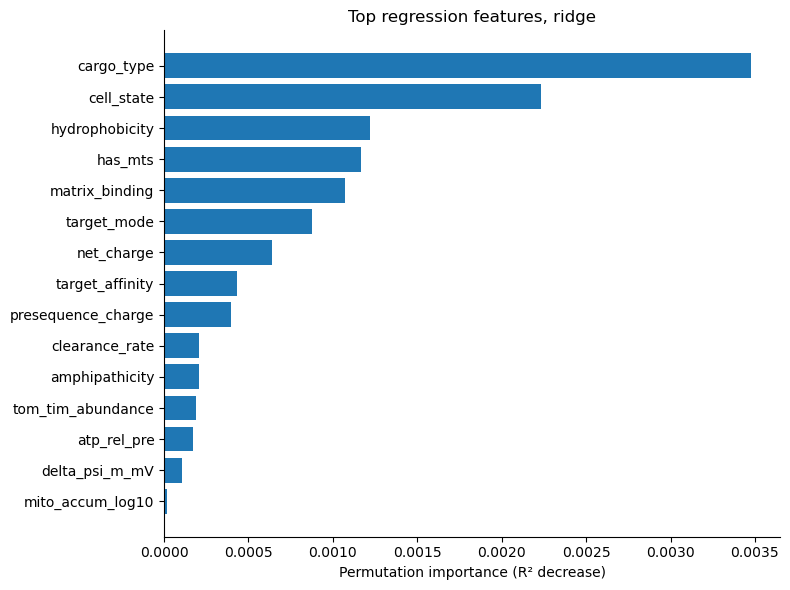

In [40]:

# CELL 25. Regression feature importance

perm_reg = permutation_importance(
    best_reg_model, X_test, y_test_reg,
    n_repeats=8, random_state=RANDOM_SEED, scoring="r2"
)

perm_reg_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_reg.importances_mean,
    "importance_std": perm_reg.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_reg_df.head(15))

top_reg = perm_reg_df.head(15).sort_values("importance_mean")
plt.figure(figsize=(8, 6))
plt.barh(top_reg["feature"], top_reg["importance_mean"])
plt.xlabel("Permutation importance (R² decrease)")
plt.title(f"Top regression features, {best_reg_name}")
plt.tight_layout()
plt.show()

                successful_programming  pred_success_prob    G_func  \
cargo_type                                                            
peptide                       0.776156           0.823313  0.530061   
small_molecule                0.466603           0.515712  0.501220   
nanoparticle                  0.017769           0.025487  0.451257   
nucleic_acid                  0.000000           0.000753  0.435275   

                pred_g_func  
cargo_type                   
peptide            0.487420  
small_molecule     0.487732  
nanoparticle       0.486950  
nucleic_acid       0.488937  


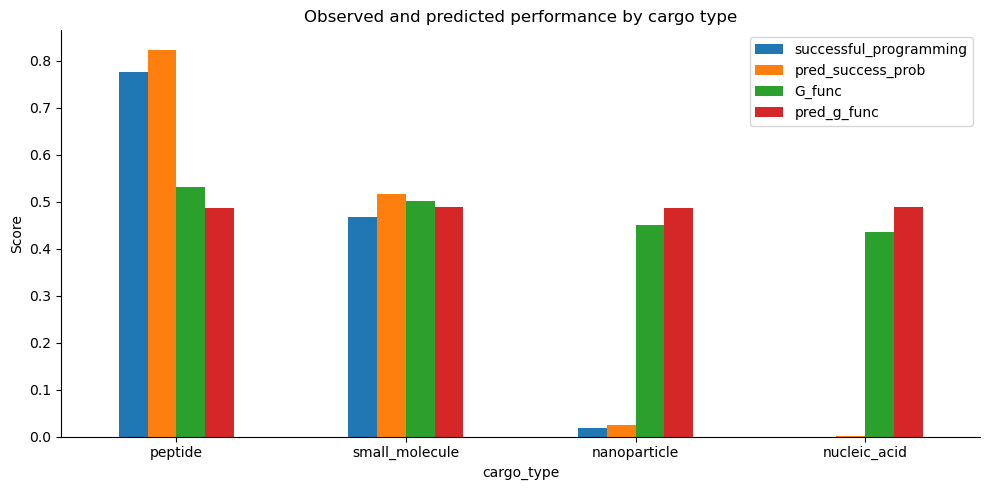

In [41]:

# CELL 26. Compare cargo types across the best model predictions

df_eval = df.copy()
df_eval["pred_success_prob"] = best_cls_model.predict_proba(df_eval[feature_cols])[:, 1]
df_eval["pred_g_func"] = best_reg_model.predict(df_eval[feature_cols])

cargo_pred_summary = df_eval.groupby("cargo_type")[[
    "successful_programming", "pred_success_prob", "G_func", "pred_g_func"
]].mean().sort_values("pred_success_prob", ascending=False)

print(cargo_pred_summary)

cargo_pred_summary[["successful_programming", "pred_success_prob", "G_func", "pred_g_func"]].plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Observed and predicted performance by cargo type")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

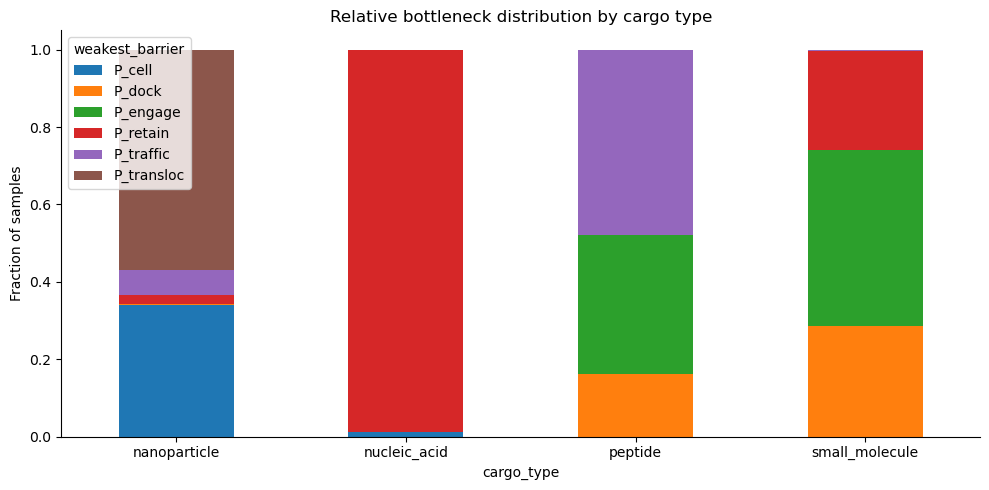

In [44]:

# CELL 27. Serial bottleneck analysis

# For each sample, identify the weakest barrier
df["weakest_barrier"] = df[step_cols].idxmin(axis=1)

bottleneck_counts = (
    df.groupby(["cargo_type", "weakest_barrier"])
      .size()
      .reset_index(name="count")
)

pivot_bottleneck = bottleneck_counts.pivot(index="cargo_type", columns="weakest_barrier", values="count").fillna(0)
pivot_bottleneck = pivot_bottleneck.div(pivot_bottleneck.sum(axis=1), axis=0)

pivot_bottleneck.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Relative bottleneck distribution by cargo type")
plt.ylabel("Fraction of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

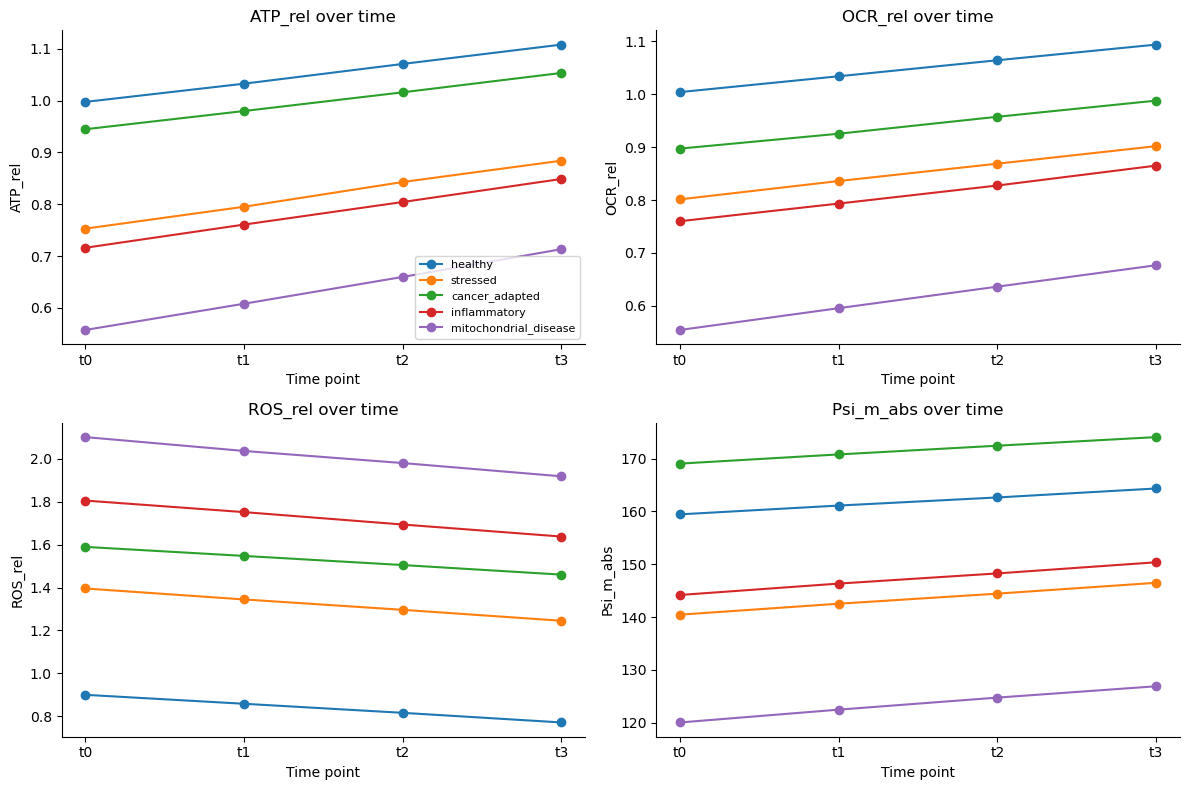

In [46]:

# CELL 28. Longitudinal trajectory plots

long_summary = long_df.groupby(["time_point", "cell_state"])[["ATP_rel", "OCR_rel", "ROS_rel", "Psi_m_abs"]].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ["ATP_rel", "OCR_rel", "ROS_rel", "Psi_m_abs"]

for ax, metric in zip(axes.flat, metrics):
    for state in cell_states:
        sub = long_summary[long_summary["cell_state"] == state]
        ax.plot(sub["time_point"], sub[metric], marker="o", label=state)
    ax.set_title(f"{metric} over time")
    ax.set_xlabel("Time point")
    ax.set_ylabel(metric)

axes[0, 0].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

In [48]:

# CELL 29. Top-ranked designs

top_designs = df.sort_values(["successful_programming", "G_func", "Phi_prog"], ascending=[False, False, False]).head(25)

cols_to_show = [
    "sample_id", "cargo_type", "cell_state", "target_mode",
    "size_kDa", "net_charge", "targeting_strength", "presequence_charge",
    "delta_psi_m_mV", "atp_rel_pre", "mito_accum_log10",
    "Phi_prog", "G_func", "successful_programming"
]

print(top_designs[cols_to_show].to_string(index=False))

 sample_id     cargo_type            cell_state         target_mode  size_kDa  net_charge  targeting_strength  presequence_charge  delta_psi_m_mV  atp_rel_pre  mito_accum_log10  Phi_prog   G_func  successful_programming
      3530 small_molecule mitochondrial_disease  membrane_modulator  0.569299    2.840997            0.496164            1.152213     -124.230392     0.200000          5.000000  0.412761 0.840976                       1
      9417        peptide mitochondrial_disease  membrane_modulator 14.211680   11.712321            0.796815            5.382706     -125.261531     0.218349          5.000000  0.486172 0.807604                       1
      3874        peptide          inflammatory protein_import_axis  9.888480    6.598302            0.534370            5.634813     -125.688150     0.224396          5.000000  0.448997 0.799273                       1
      2479        peptide mitochondrial_disease protein_import_axis 12.427097    4.037607            0.944507           

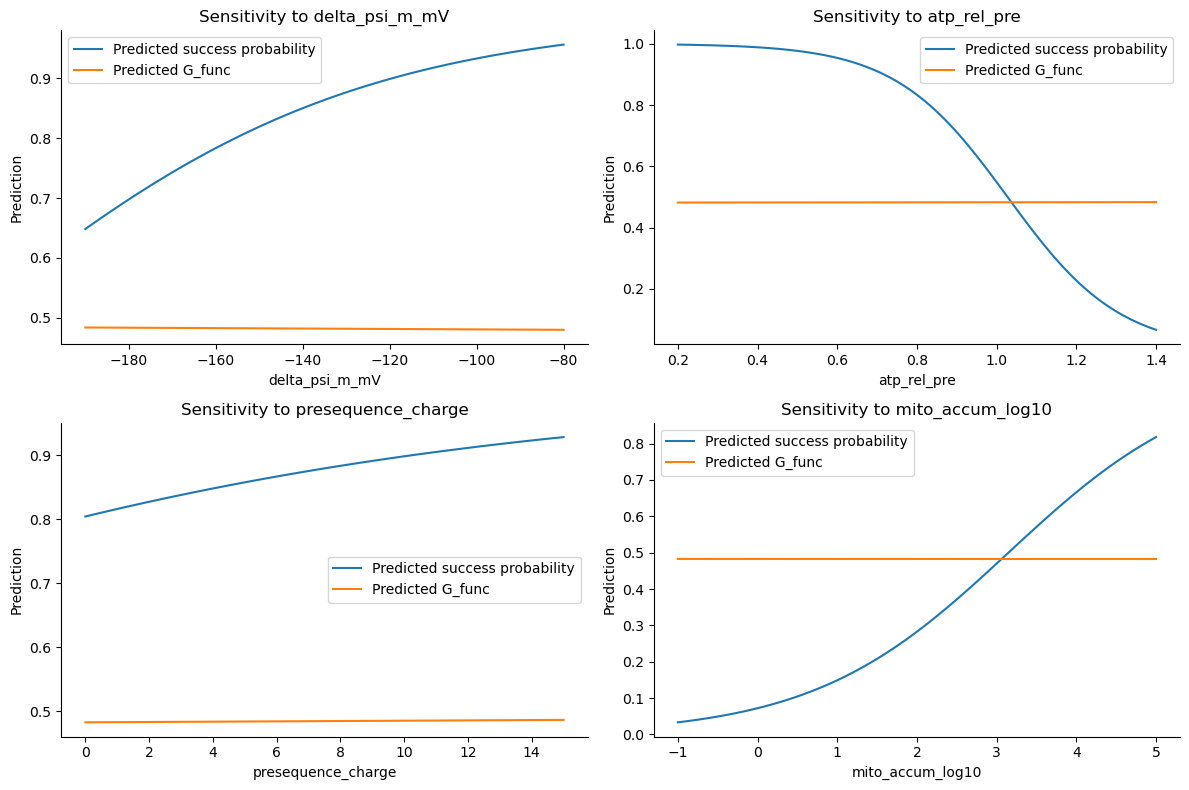

In [50]:

# CELL 30. Sensitivity analysis around key parameters

# Sweep one feature at a time while keeping others near median
base = df[feature_cols].median(numeric_only=True).to_dict()
base["cargo_type"] = "peptide"
base["cell_state"] = "healthy"
base["target_mode"] = "protein_import_axis"

sweep_features = {
    "delta_psi_m_mV": np.linspace(-190, -80, 100),
    "atp_rel_pre": np.linspace(0.2, 1.4, 100),
    "presequence_charge": np.linspace(0, 15, 100),
    "mito_accum_log10": np.linspace(-1, 5, 100)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (feat, values) in zip(axes.flat, sweep_features.items()):
    records = []
    for v in values:
        row = base.copy()
        row[feat] = v
        xrow = pd.DataFrame([row])[feature_cols]
        pred_prob = best_cls_model.predict_proba(xrow)[:, 1][0]
        pred_g = best_reg_model.predict(xrow)[0]
        records.append((v, pred_prob, pred_g))
    tmp = pd.DataFrame(records, columns=[feat, "pred_success_prob", "pred_g"])
    ax.plot(tmp[feat], tmp["pred_success_prob"], label="Predicted success probability")
    ax.plot(tmp[feat], tmp["pred_g"], label="Predicted G_func")
    ax.set_title(f"Sensitivity to {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Prediction")
    ax.legend()

plt.tight_layout()
plt.show()

In [51]:

# CELL 31. Cross-validation summary

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

cv_pipe_cls = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=250, min_samples_leaf=2, random_state=RANDOM_SEED,
        n_jobs=-1, class_weight="balanced_subsample"
    ))
])

cv_pipe_reg = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=250, min_samples_leaf=2, random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

cv_auc = cross_val_score(cv_pipe_cls, X, y_cls, cv=cv, scoring="roc_auc", n_jobs=-1)
cv_r2 = cross_val_score(cv_pipe_reg, X, y_reg, cv=cv, scoring="r2", n_jobs=-1)

print("5-fold CV ROC-AUC:", cv_auc, "mean =", cv_auc.mean().round(4), "std =", cv_auc.std().round(4))
print("5-fold CV R²:", cv_r2, "mean =", cv_r2.mean().round(4), "std =", cv_r2.std().round(4))

5-fold CV ROC-AUC: [0.96688117 0.97419132 0.96668414 0.96492333 0.96784988] mean = 0.9681 std = 0.0032
5-fold CV R²: [0.83854203 0.85445207 0.84530898 0.84268556 0.85689193] mean = 0.8476 std = 0.007


In [53]:

# CELL 32. Compact report table

report = {
    "n_samples_main": len(df),
    "n_samples_longitudinal": len(long_df),
    "success_rate": float(df["successful_programming"].mean()),
    "strong_rescue_rate": float(df["strong_rescue"].mean()),
    "best_classifier": best_cls_name,
    "best_classifier_roc_auc": float(cls_results_df.iloc[0]["roc_auc"]),
    "best_regressor": best_reg_name,
    "best_regressor_r2": float(reg_results_df.iloc[0]["r2"])
}

report_df = pd.DataFrame([report])
print(report_df.T)

                                           0
n_samples_main                         12000
n_samples_longitudinal                 16000
success_rate                        0.378667
strong_rescue_rate                    0.0065
best_classifier          logistic_regression
best_classifier_roc_auc             0.976723
best_regressor                         ridge
best_regressor_r2                   -0.00577


In [54]:

# CELL 33. Export key outputs

summary_cargo.to_csv("summary_by_cargo_type.csv")
summary_state.to_csv("summary_by_cell_state.csv")
cls_results_df.to_csv("classification_results.csv", index=False)
reg_results_df.to_csv("regression_results.csv", index=False)
perm_importance.to_csv("classification_permutation_importance.csv", index=False)
perm_reg_df.to_csv("regression_permutation_importance.csv", index=False)
top_designs[cols_to_show].to_csv("top_ranked_designs.csv", index=False)
report_df.to_csv("simulation_report.csv", index=False)

print("Key analysis outputs exported.")

Key analysis outputs exported.


In [55]:

# CELL 34. Optional: quick interpretation text

print("Top classifier:", best_cls_name)
print("Top regressor:", best_reg_name)
print("\nTop classification features:")
print(perm_importance.head(10)[["feature", "importance_mean"]].to_string(index=False))

print("\nTop regression features:")
print(perm_reg_df.head(10)[["feature", "importance_mean"]].to_string(index=False))

print("\nMost common bottlenecks:")
print(df["weakest_barrier"].value_counts(normalize=True).round(3).to_string())

Top classifier: logistic_regression
Top regressor: ridge

Top classification features:
         feature  importance_mean
        size_kDa         0.150965
mito_accum_log10         0.093760
     atp_rel_pre         0.043228
  clearance_rate         0.018846
      cargo_type         0.017810
    baseline_ocr         0.014051
         has_mts         0.006976
         has_tpp         0.005840
  delta_psi_m_mV         0.004807
    baseline_ros         0.004281

Top regression features:
           feature  importance_mean
        cargo_type         0.003475
        cell_state         0.002235
    hydrophobicity         0.001223
           has_mts         0.001169
    matrix_binding         0.001072
       target_mode         0.000879
        net_charge         0.000637
   target_affinity         0.000432
presequence_charge         0.000394
    clearance_rate         0.000208

Most common bottlenecks:
weakest_barrier
P_retain      0.268
P_engage      0.258
P_traffic     0.145
P_dock        0